<a href="https://colab.research.google.com/github/QasimNiazi86/Segmentation-UNet/blob/main/Tutorial10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cuda
Test 1: Standard Learning Rate (1e-4)

--- Starting Training with Learning Rate: 0.0001 ---
Epoch [1/10], Training Loss: 0.7146
Epoch [2/10], Training Loss: 0.6896
Epoch [3/10], Training Loss: 0.6172
Epoch [4/10], Training Loss: 0.2652
Epoch [5/10], Training Loss: 0.0369
Epoch [6/10], Training Loss: 0.0235
Epoch [7/10], Training Loss: 0.0156
Epoch [8/10], Training Loss: 0.0124
Epoch [9/10], Training Loss: 0.0110
Epoch [10/10], Training Loss: 0.0091

--- Evaluating Model ---
Validation Loss: 0.0085


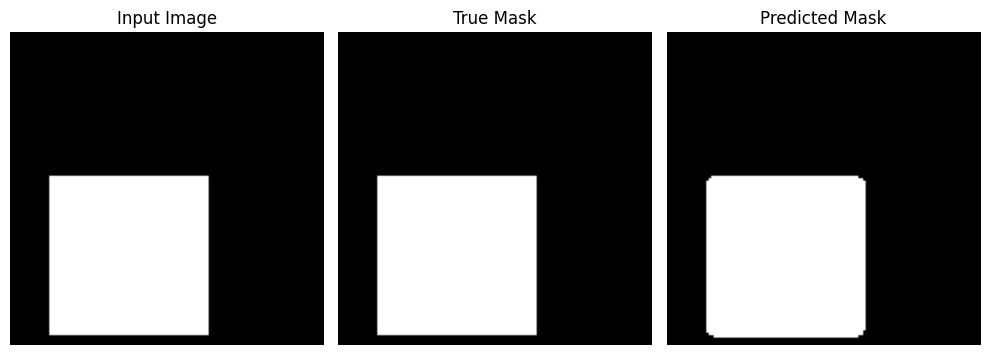

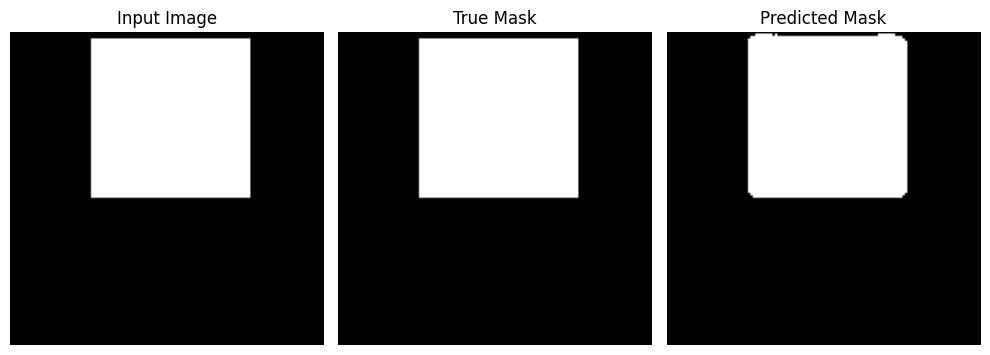

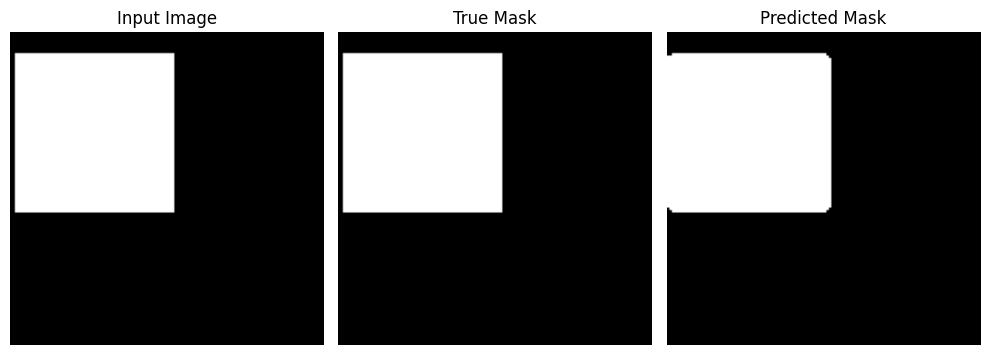


Test 2: High Learning Rate (1e-2) to observe potential divergence

--- Starting Training with Learning Rate: 0.01 ---
Epoch [1/10], Training Loss: 3.6647
Epoch [2/10], Training Loss: 0.6886
Epoch [3/10], Training Loss: 0.6086
Epoch [4/10], Training Loss: 0.5897
Epoch [5/10], Training Loss: 0.5117
Epoch [6/10], Training Loss: 0.2975
Epoch [7/10], Training Loss: 0.1944
Epoch [8/10], Training Loss: 0.1703
Epoch [9/10], Training Loss: 0.0674
Epoch [10/10], Training Loss: 0.0011

--- Evaluating Model ---
Validation Loss: 0.0000


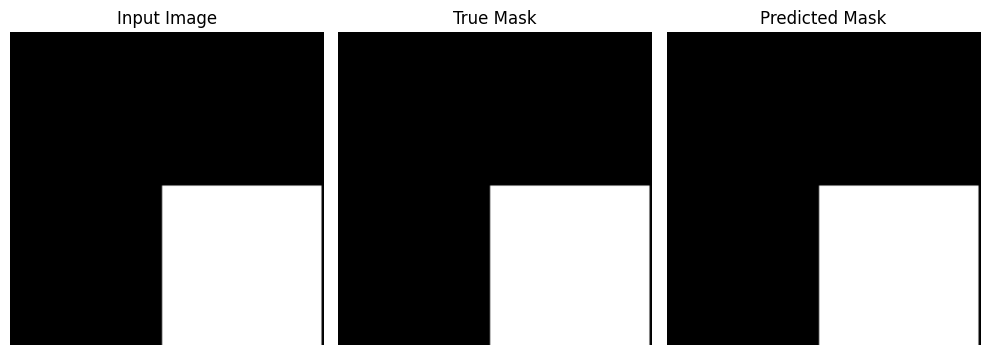

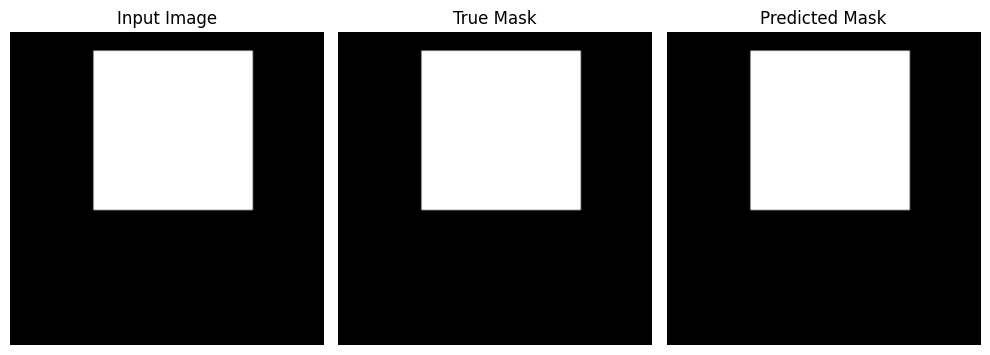

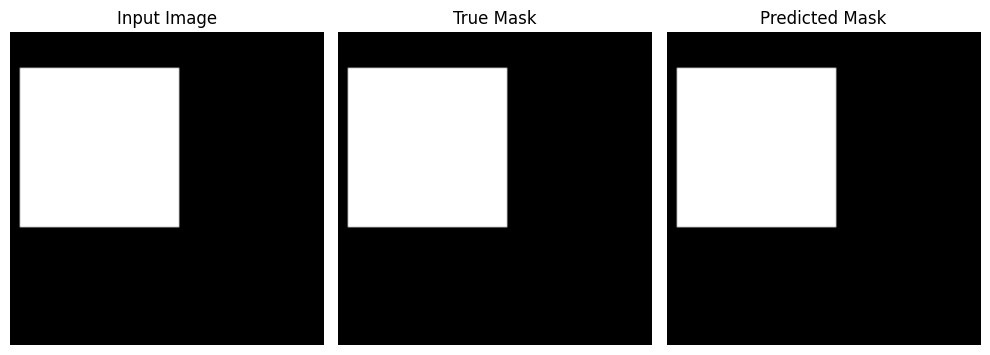

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import cv2

# ==========================================
# Device Configuration
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==========================================
# Part 1: Prepare the Dataset
# ==========================================
# Generating synthetic data with rectangles as described in the tutorial
def create_sample_data(img_size=128, num_samples=100):
    images = []
    masks = []

    for i in range(num_samples):
        # Initialize blank image and mask
        img = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        mask = np.zeros((img_size, img_size, 1), dtype=np.uint8)

        # Add a random rectangle
        x1, y1 = np.random.randint(0, img_size // 2, 2)
        x2, y2 = x1 + img_size // 2, y1 + img_size // 2

        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 255), -1)
        cv2.rectangle(mask, (x1, y1), (x2, y2), 1, -1)

        images.append(img)
        masks.append(mask)

    # PyTorch expects channels first: (Batch, Channels, Height, Width)
    images = np.array(images).transpose((0, 3, 1, 2)) / 255.0
    masks = np.array(masks).transpose((0, 3, 1, 2))

    return torch.tensor(images, dtype=torch.float32), torch.tensor(masks, dtype=torch.float32)

# ==========================================
# Part 2: Define the Custom U-Net Model
# ==========================================
class DoubleConv(nn.Module):
    """Helper module for two consecutive convolutional layers with ReLU"""
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            # Using padding=1 to replicate padding='same'
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        # Encoder (Downsampling)
        self.down1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder (Upsampling & Concatenation)
        # Using ConvTranspose2d instead of UpSampling2D for learnable upscaling
        self.up1 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv_up1 = DoubleConv(256, 128) # 256 because of concatenation (128 + 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv_up2 = DoubleConv(128, 64)  # 128 because of concatenation (64 + 64)

        # Output layer
        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # Encoder
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        # Bottleneck
        c3 = self.bottleneck(p2)

        # Decoder
        u1 = self.up1(c3)
        u1 = torch.cat([u1, c2], dim=1) # Skip connection
        c4 = self.conv_up1(u1)

        u2 = self.up2(c4)
        u2 = torch.cat([u2, c1], dim=1) # Skip connection
        c5 = self.conv_up2(u2)

        outputs = self.sigmoid(self.out_conv(c5))
        return outputs

# ==========================================
# Part 3: Visualizer Function
# ==========================================
def plot_sample(image, true_mask, pred_mask):
    """Plots the original image, ground truth mask, and predicted mask."""
    # Convert PyTorch tensors back to numpy for matplotlib (Height, Width, Channels)
    image = image.permute(1, 2, 0).cpu().numpy()
    true_mask = true_mask.squeeze().cpu().numpy()
    pred_mask = pred_mask.squeeze().cpu().numpy()

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 3, 1)
    plt.title("Input Image")
    plt.imshow(image)
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title("True Mask")
    plt.imshow(true_mask, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title("Predicted Mask")
    # Apply threshold of 0.5 to prediction probabilities
    plt.imshow((pred_mask > 0.5).astype(np.uint8), cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# ==========================================
# Part 4: Training & Task Execution
# ==========================================
def train_and_evaluate(learning_rate=1e-4, epochs=10):
    print(f"\n--- Starting Training with Learning Rate: {learning_rate} ---")

    # 1. Generate Data
    images, masks = create_sample_data(img_size=128, num_samples=100)
    dataset = TensorDataset(images, masks)

    # Split data into training (80%) and validation (20%) sets
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

    # 2. Initialize Model, Loss, and Optimizer
    model = UNet().to(device)
    criterion = nn.BCELoss() # Binary Cross-Entropy
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # 3. Training Loop
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0

        for batch_images, batch_masks in train_loader:
            batch_images, batch_masks = batch_images.to(device), batch_masks.to(device)

            # Forward pass
            outputs = model(batch_images)
            loss = criterion(outputs, batch_masks)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Training Loss: {epoch_loss/len(train_loader):.4f}")

    # 4. Evaluation and Visualization
    model.eval()
    val_loss = 0
    print("\n--- Evaluating Model ---")
    with torch.no_grad():
        for batch_images, batch_masks in val_loader:
            batch_images, batch_masks = batch_images.to(device), batch_masks.to(device)
            outputs = model(batch_images)
            loss = criterion(outputs, batch_masks)
            val_loss += loss.item()

        print(f"Validation Loss: {val_loss/len(val_loader):.4f}")

        # Visualize 3 samples from the validation set
        sample_images, sample_masks = next(iter(val_loader))
        sample_preds = model(sample_images.to(device))

        for i in range(3):
            plot_sample(sample_images[i], sample_masks[i], sample_preds[i])

if __name__ == "__main__":
    # Task: Use different learning rates and visualize the results
    # We will test with a standard learning rate (1e-4) and a higher one (1e-2)

    print("Test 1: Standard Learning Rate (1e-4)")
    train_and_evaluate(learning_rate=1e-4, epochs=10)

    print("\nTest 2: High Learning Rate (1e-2) to observe potential divergence")
    train_and_evaluate(learning_rate=1e-2, epochs=10)